In [1]:
import os
import glob
from enum import Enum

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [ ]:
pred = os.path.join(os.path.split(os.getcwd())[0], "predictions")
predictions_vanilla = glob.glob(os.path.join(pred, 'vanilla', "*.json"))
predictions_kbrs = glob.glob(os.path.join(pred, 'kbrs', "*.json"))
reps = [f"{os.path.basename(pred).split('_')[0]}.rep" for pred in predictions_vanilla]

In [4]:
# open json files and load them
predictions_vanilla_data = []
predictions_kbrs_data = []

for pred in predictions_vanilla:
    with open(pred, 'r') as f:
        data = json.load(f)
        predictions_vanilla_data.append(data)

for pred in predictions_kbrs:
    with open(pred, 'r') as f:
        data = json.load(f)
        predictions_kbrs_data.append(data)

In [5]:
annotations_vanilla = pd.DataFrame(predictions_vanilla_data[0]['annotations'])
annotations_kbrs = pd.DataFrame(predictions_kbrs_data[0]['annotations'])

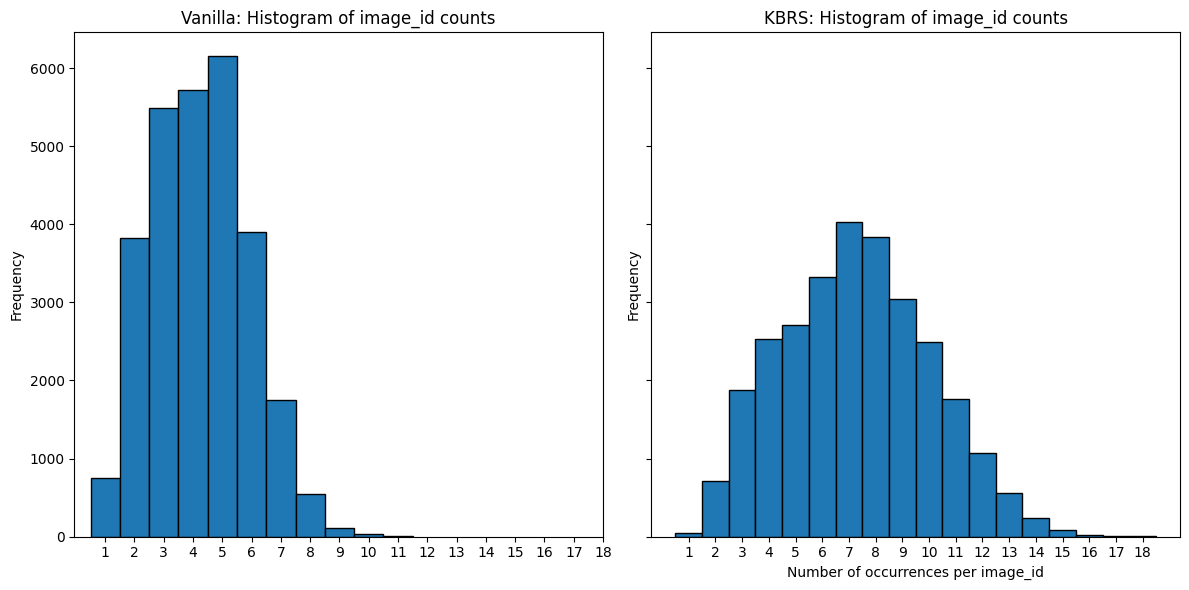

In [7]:
counts_vanilla = annotations_vanilla.groupby('image_id').size()
counts_kbrs = annotations_kbrs.groupby('image_id').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].hist(
    counts_vanilla,
    bins=range(1, counts_vanilla.max() + 2),
    edgecolor='black',
    align='left'
)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Vanilla: Histogram of image_id counts')
axes[0].set_xticks(range(1, max(counts_vanilla.max(), counts_kbrs.max()) + 1))

axes[1].hist(
    counts_kbrs,
    bins=range(1, counts_kbrs.max() + 2),
    edgecolor='black',
    align='left'
)
axes[1].set_xlabel('Number of occurrences per image_id')
axes[1].set_ylabel('Frequency')
axes[1].set_title('KBRS: Histogram of image_id counts')
axes[1].set_xticks(range(1, max(counts_vanilla.max(), counts_kbrs.max()) + 1))

plt.tight_layout()

plt.show()

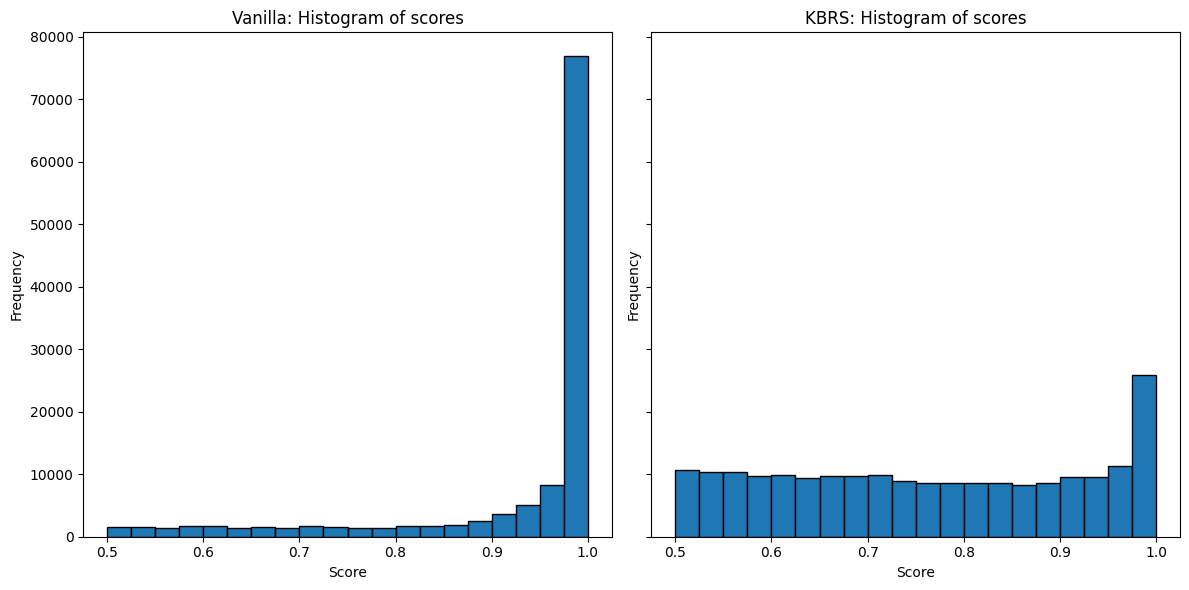

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].hist(annotations_vanilla['score'], bins=20, edgecolor='black')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Vanilla: Histogram of scores')


axes[1].hist(annotations_kbrs['score'], bins=20, edgecolor='black')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('KBRS: Histogram of scores')

plt.tight_layout()
plt.show()

In [42]:
def draw_overview(data, rep_name, frame, ground_truths=None, segmentations_list=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    ax = plt.gca()

    # --- Segmentation Overlays (여러 개) ---
    if segmentations_list is not None:
        colors = ['red', 'blue']  # 두 개 세그먼트용 색상
        for seg_idx, segmentations in enumerate(segmentations_list):
            for seg in segmentations:
                coords = np.array(seg[0]).reshape(-1, 2)
                polygon = patches.Polygon(
                    coords,
                    linewidth=1.5,
                    edgecolor=colors[seg_idx % len(colors)],
                    facecolor='none'
                )
                ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        gt_color = 'green'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(
                coords,
                linewidth=1.5,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(polygon)

    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(
        f'figures/{rep_name}/{rep_name}_{frame}_Overview.png',
        bbox_inches='tight',
        pad_inches=0
    )
    # plt.show()


In [ ]:
common_ids = np.intersect1d(annotations_vanilla['image_id'].unique(), annotations_kbrs['image_id'].unique())
random_ids = np.random.choice(common_ids, replace=False)
print(f"Randomly selected image_ids: {random_ids}")

prediction_vanilla_results = annotations_vanilla.loc[annotations_vanilla['image_id'] == random_ids]
prediction_kbrs_results = annotations_kbrs.loc[annotations_kbrs['image_id'] == random_ids]
print(f"Number of predictions for {random_ids} - vannila: {len(prediction_vanilla_results)} kbrs: {len(prediction_kbrs_results)}")

images = predictions_vanilla_data[0]['images']
image_path = next((item for item in images if item['id'] == random_ids), None)

input_root = os.path.join(os.path.split(os.getcwd())[0], "data", "input", "dst")
input_path = os.path.join(input_root, image_path['file_name'])
input_numpy = np.load(input_path)

rep_name, frame_npy = image_path['file_name'].split('/')

ground_truth_root = os.path.join(os.path.split(os.getcwd())[0], "data", "label", "dst")
ground_truth_path = os.path.join(ground_truth_root, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

df_gt = pd.DataFrame(ground_truth_all_correct['annotations'])
ground_truths = df_gt.loc[df_gt['image_id'] == random_ids]

Randomly selected image_ids: 11771
Number of predictions for 11771 - vannila: 2 kbrs: 5


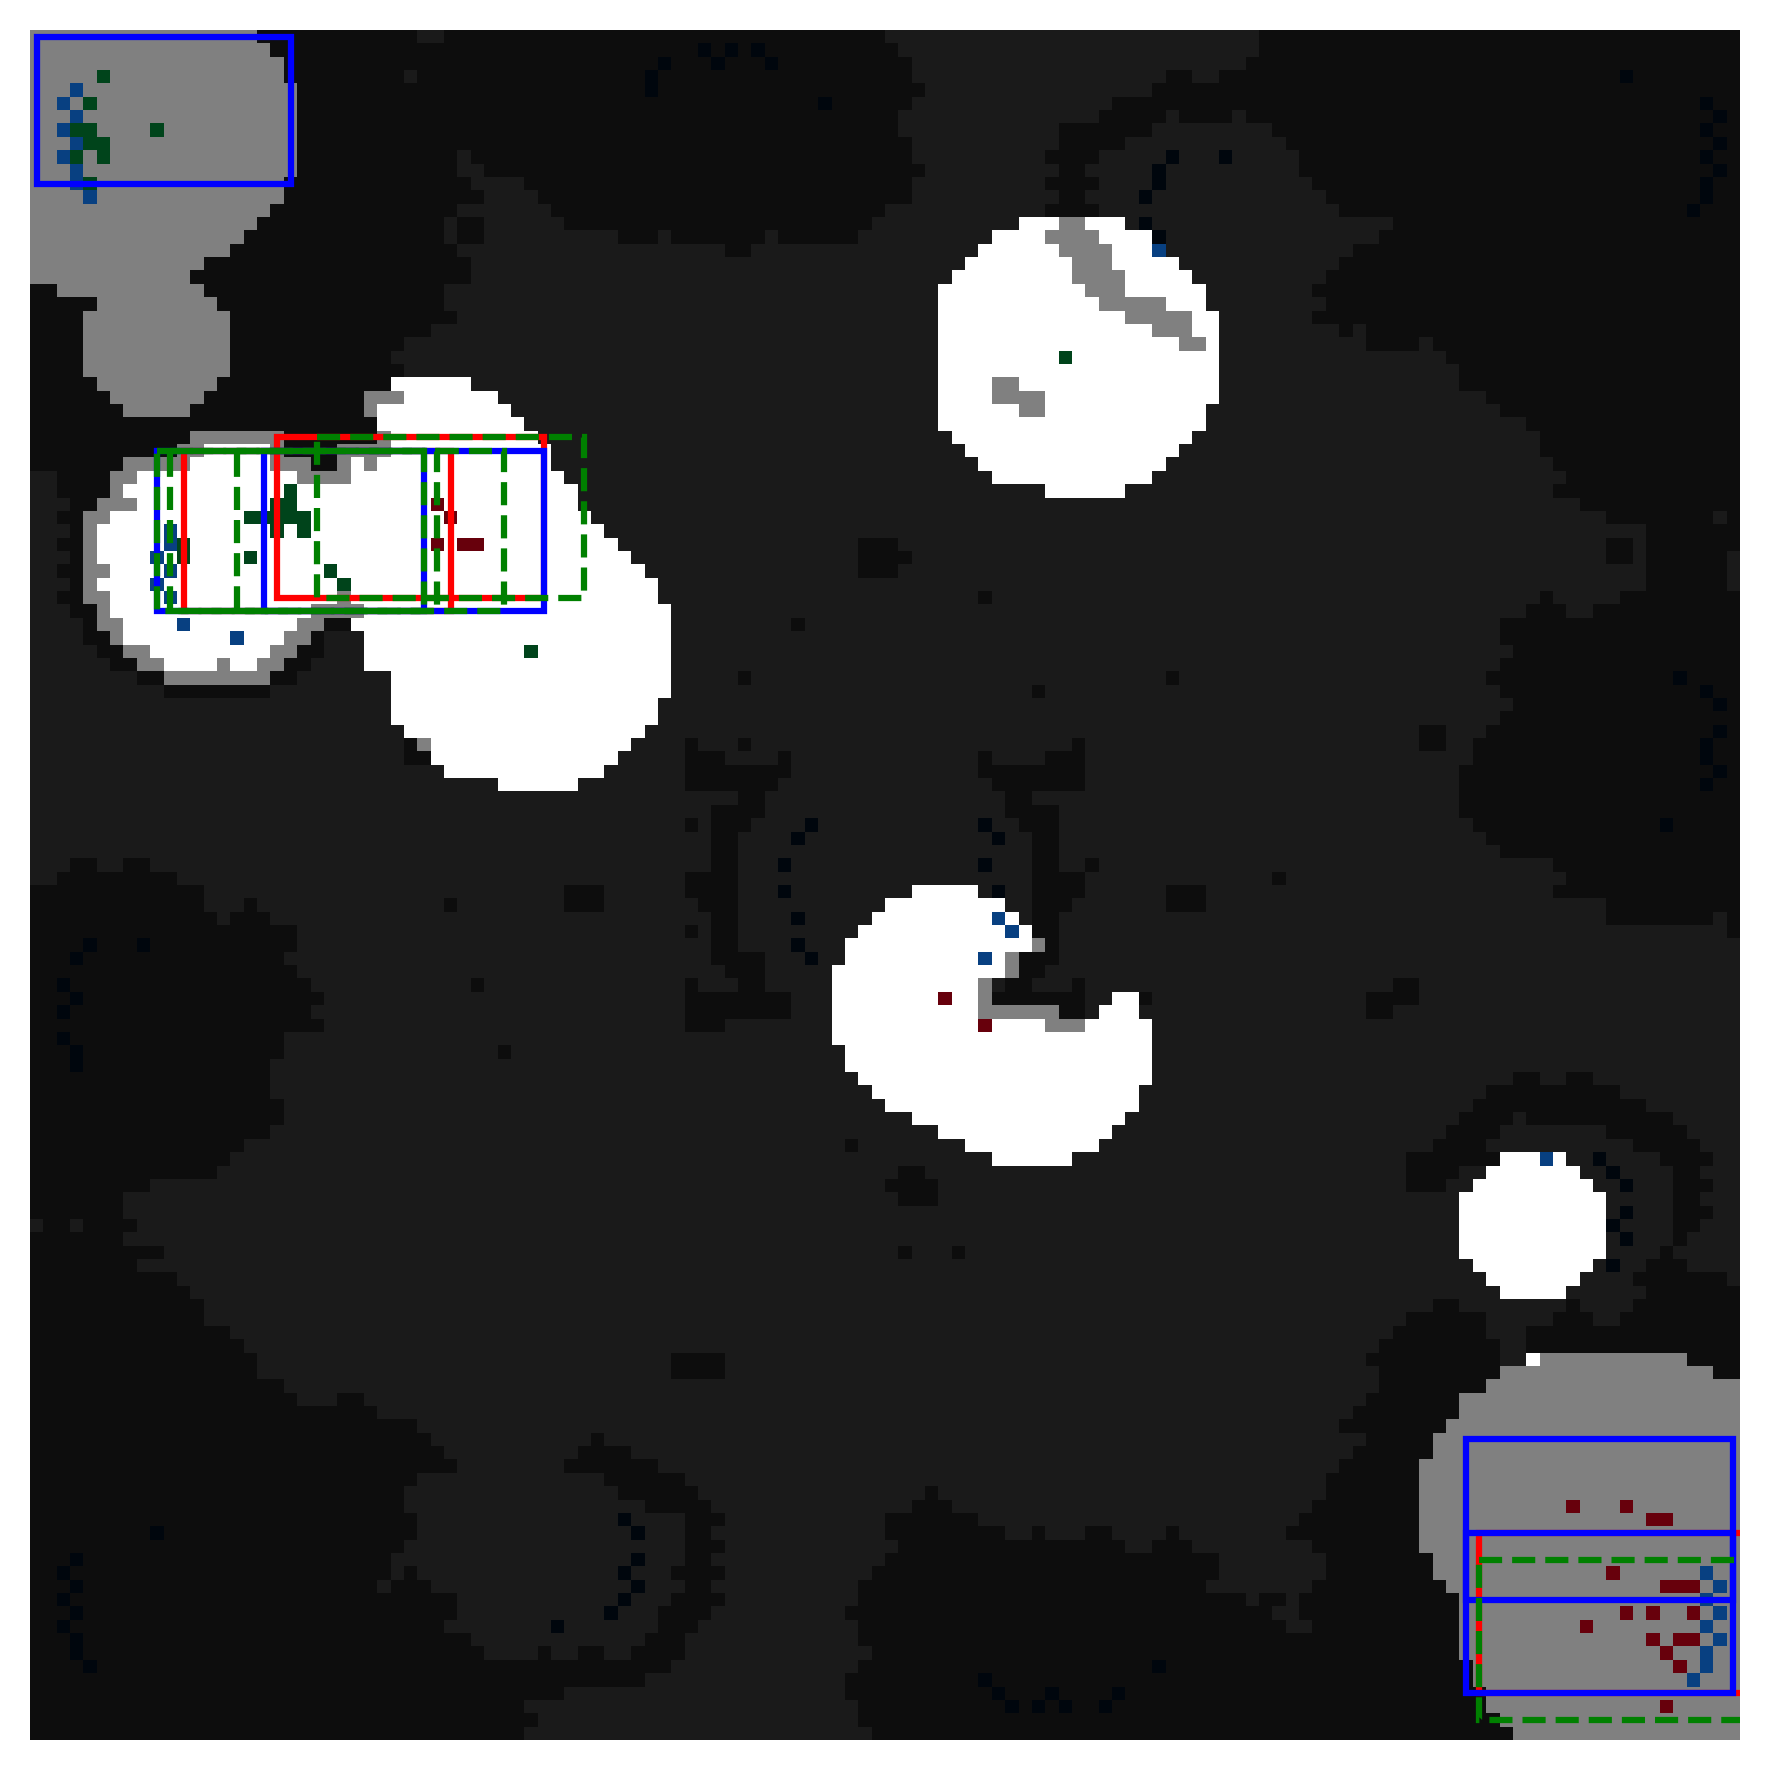

In [55]:
draw_overview(input_numpy,
              rep_name,
              frame_npy.split('.')[0], 
              ground_truths=ground_truths['segmentation'],
              segmentations_list=[prediction_vanilla_results['segmentation'].tolist(), prediction_kbrs_results['segmentation']])